In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [22]:
df = pd.read_csv("traffic.csv")
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [23]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [24]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month

df.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11


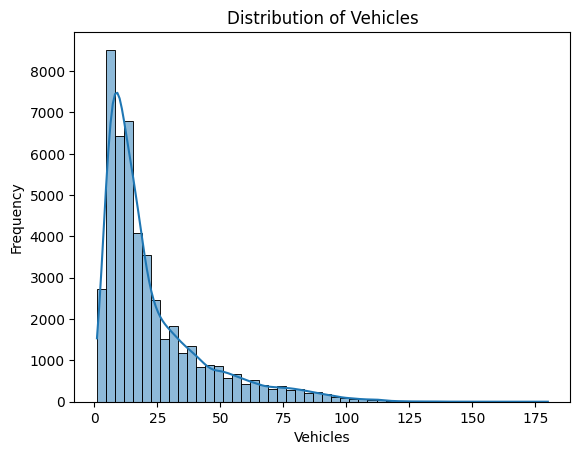

In [25]:
plt.figure()
sns.histplot(df['Vehicles'], bins=50, kde=True)
plt.title("Distribution of Vehicles")
plt.xlabel("Vehicles")
plt.ylabel("Frequency")
plt.show()

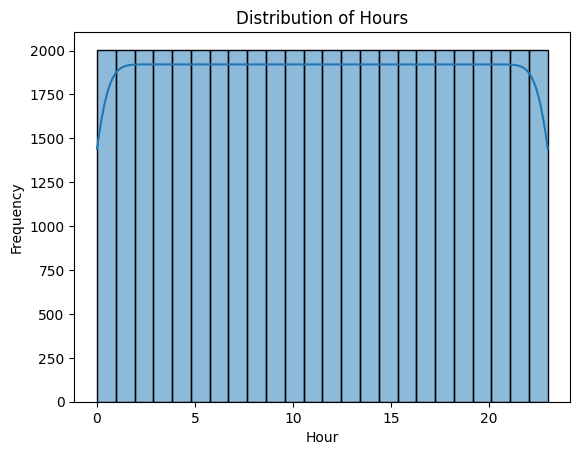

In [26]:
plt.figure()
sns.histplot(df['Hour'], bins=24, kde=True)
plt.title("Distribution of Hours")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

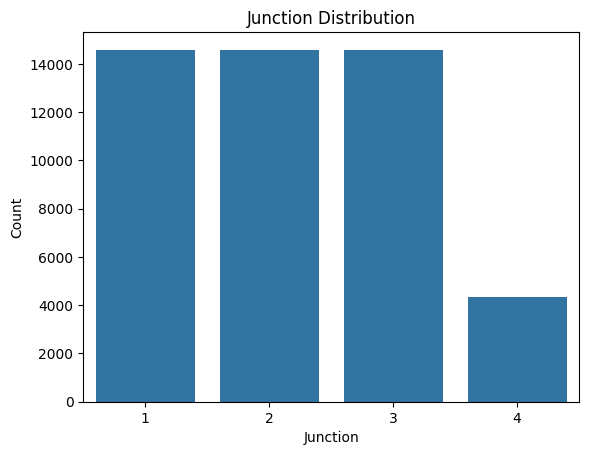

In [27]:
plt.figure()
sns.countplot(x=df['Junction'])
plt.title("Junction Distribution")
plt.xlabel("Junction")
plt.ylabel("Count")
plt.show()

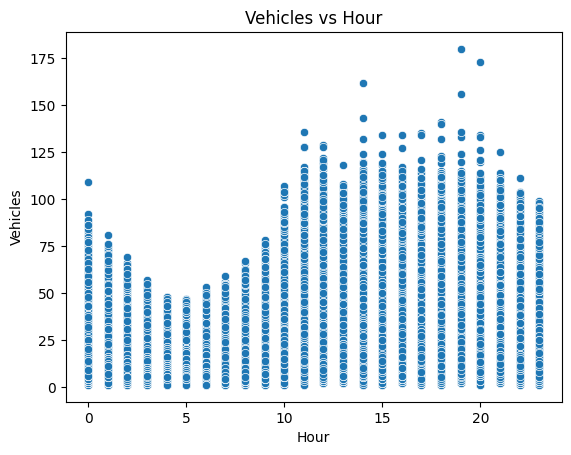

In [28]:
plt.figure()
sns.scatterplot(x=df['Hour'], y=df['Vehicles'])
plt.title("Vehicles vs Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.show()

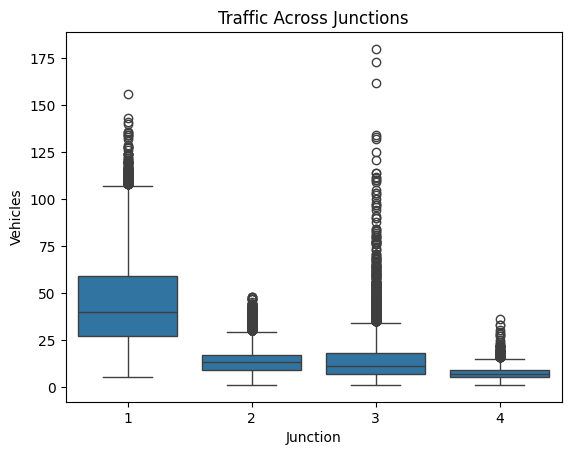

In [29]:
plt.figure()
sns.boxplot(x=df['Junction'], y=df['Vehicles'])
plt.title("Traffic Across Junctions")
plt.xlabel("Junction")
plt.ylabel("Vehicles")
plt.show()

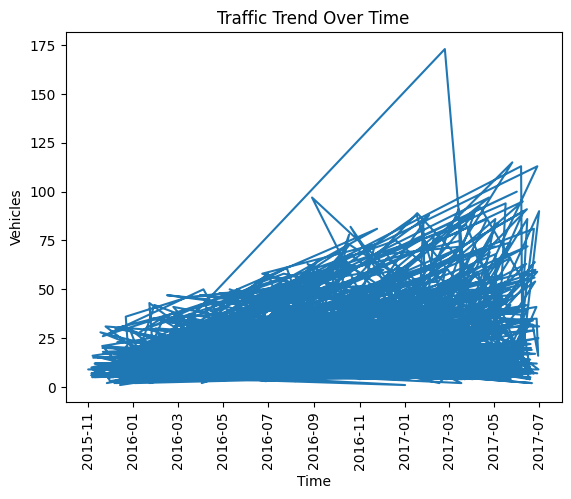

In [30]:
sample_df = df.sample(1000, random_state=42)

plt.figure()
plt.plot(sample_df['DateTime'], sample_df['Vehicles'])
plt.title("Traffic Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Vehicles")
plt.xticks(rotation=90)
plt.show()

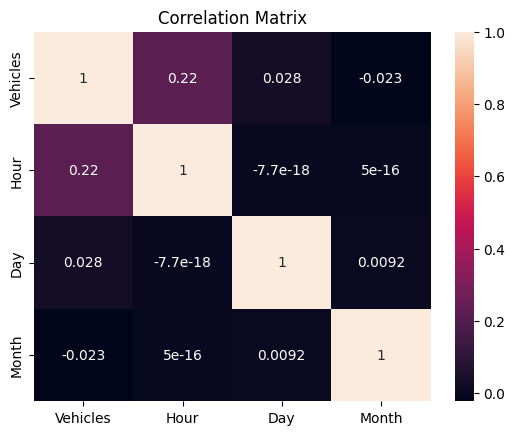

In [31]:
plt.figure()
sns.heatmap(df[['Vehicles','Hour','Day','Month']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [32]:
X = df[['Vehicles', 'Hour']]

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

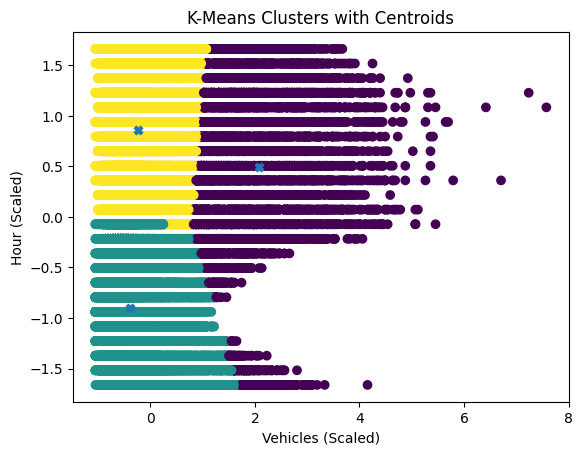

In [35]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'])
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X')

plt.xlabel("Vehicles (Scaled)")
plt.ylabel("Hour (Scaled)")
plt.title("K-Means Clusters with Centroids")
plt.show()

In [36]:
df.groupby('Cluster')[['Vehicles', 'Hour']].mean()

,Vehicles,Hour
Cluster,,
0,66.119378,14.894331
1,14.540504,5.284272
2,17.738236,17.457701


In [37]:
print("Cluster 0 → Low traffic (off-peak hours)")
print("Cluster 1 → Medium traffic")
print("Cluster 2 → High traffic (peak hours)")

Cluster 0 → Low traffic (off-peak hours)
Cluster 1 → Medium traffic
Cluster 2 → High traffic (peak hours)
